Shape: (1000, 8)

First 5 rows:
   age         job   marital  education  balance  duration  campaign    y
0   56    services    single  secondary     3107       276         3   no
1   69    services  divorced   tertiary     7543       644         9   no
2   46       admin    single    primary       22       342         5   no
3   32     retired    single   tertiary     5404       424         3   no
4   60  management  divorced    primary     4388       570         5  yes

Loan Acceptance Count:
y
no     529
yes    471
Name: count, dtype: int64


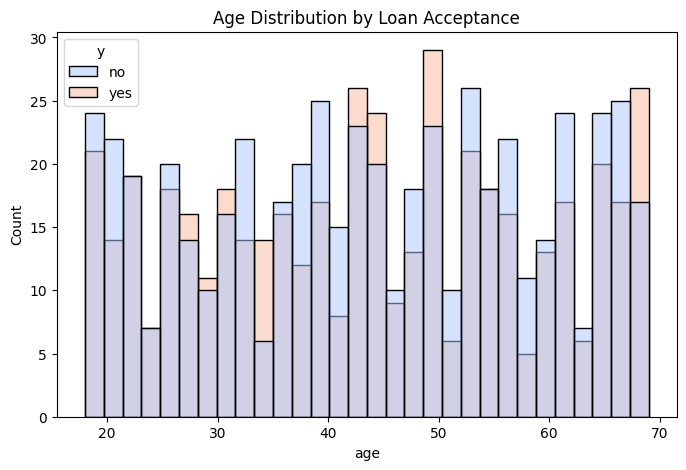

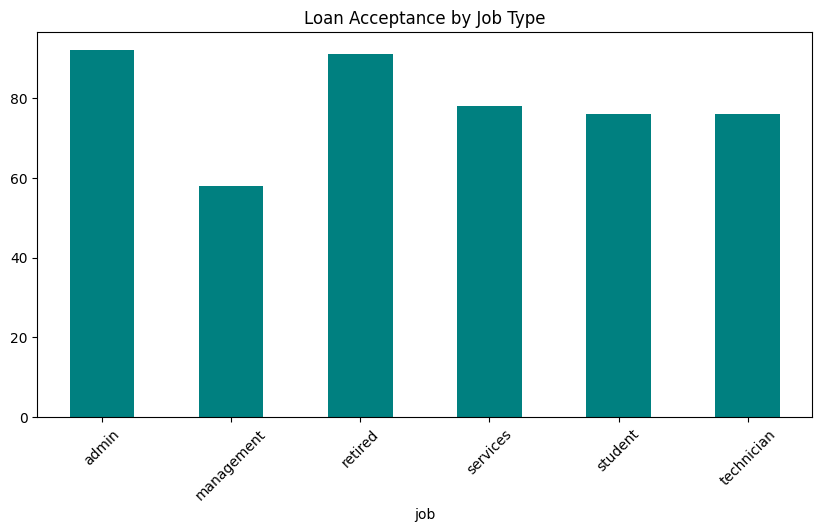

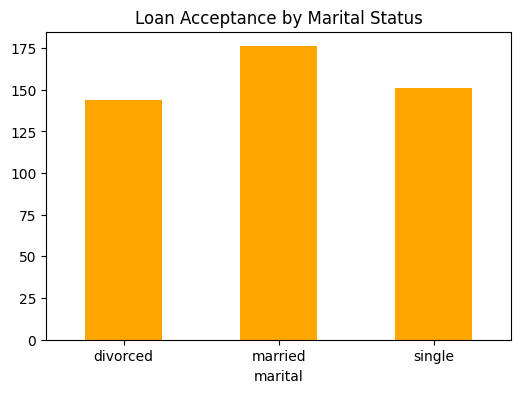


Accuracy: 0.485


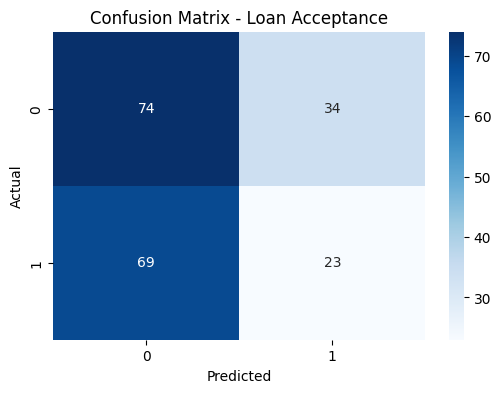


Acceptance by Marital Status:
marital
0    0.458599
1    0.520710
2    0.433908
Name: y, dtype: float64


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Create sample Bank Marketing dataset
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'age': np.random.randint(18, 70, n),
    'job': np.random.choice(['admin','technician',
                             'services','management',
                             'retired','student'], n),
    'marital': np.random.choice(['married',
                                 'single','divorced'], n),
    'education': np.random.choice(['primary',
                                   'secondary','tertiary'], n),
    'balance': np.random.randint(-500, 10000, n),
    'duration': np.random.randint(0, 900, n),
    'campaign': np.random.randint(1, 10, n),
    'y': np.random.choice(['yes','no'], n)
})

# Basic Exploration
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLoan Acceptance Count:")
print(df['y'].value_counts())

# Visualize Age distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='y',
             bins=30, palette='coolwarm')
plt.title('Age Distribution by Loan Acceptance')
plt.show()

# Visualize Job vs Acceptance
plt.figure(figsize=(10,5))
df.groupby('job')['y'].apply(
    lambda x: (x=='yes').sum()).plot(
    kind='bar', color='teal')
plt.title('Loan Acceptance by Job Type')
plt.xticks(rotation=45)
plt.show()

# Visualize Marital Status
plt.figure(figsize=(6,4))
df.groupby('marital')['y'].apply(
    lambda x: (x=='yes').sum()).plot(
    kind='bar', color='orange')
plt.title('Loan Acceptance by Marital Status')
plt.xticks(rotation=0)
plt.show()

# Encode categorical features
le = LabelEncoder()
for col in ['job','marital','education','y']:
    df[col] = le.fit_transform(df[col])

# Train/Test Split
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Loan Acceptance')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Customer Groups Analysis
print("\nAcceptance by Marital Status:")
print(df.groupby('marital')['y'].mean())